In [3]:
import re
import pandas as pd
import spacy
from collections import Counter
import matplotlib.pyplot as plt

# Load the pretrained English NER model from spaCy
nlp = spacy.load("en_core_web_sm")

print("Libraries loaded successfully.")
print("spaCy pipeline components:", nlp.pipe_names)


Libraries loaded successfully.
spaCy pipeline components: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


In [4]:
DATA_PATH = r"D:\Amr\Portfolio\All time project\ready to publish\NLP\Project 4\Resume.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (2484, 4)


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [5]:
print("Columns:", list(df.columns))
print()
print(df.info())
print()
print("Missing values per column:")
print(df.isnull().sum())

# If a 'Category' column exists, show the distribution
if "Category" in df.columns:
    print()
    print("Resume category distribution:")
    print(df["Category"].value_counts())


Columns: ['ID', 'Resume_str', 'Resume_html', 'Category']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB
None

Missing values per column:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

Resume category distribution:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT               

In [6]:
# Adjust this if your dataset uses a different column name for resume text
TEXT_COLUMN = "Resume_str" if "Resume_str" in df.columns else df.columns[0]
print("Using text column:", TEXT_COLUMN)

before = len(df)
df = df.dropna(subset=[TEXT_COLUMN]).reset_index(drop=True)
after = len(df)
print(f"Dropped {before - after} rows with missing resume text. Remaining rows: {after}")


Using text column: Resume_str
Dropped 0 rows with missing resume text. Remaining rows: 2484


In [7]:
def clean_resume_text(text: str) -> str:
    text = re.sub(r"\s+", " ", text)          # collapse multiple whitespace/newlines
    text = re.sub(r"[•●▪]", "-", text)          # normalize bullet symbols
    text = re.sub(r"http\S+", "", text)         # remove URLs
    return text.strip()

df["clean_text"] = df[TEXT_COLUMN].apply(clean_resume_text)

# Preview before/after for the first resume
print("--- BEFORE ---")
print(df[TEXT_COLUMN].iloc[0][:300])
print()
print("--- AFTER ---")
print(df["clean_text"].iloc[0][:300])


--- BEFORE ---
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commit

--- AFTER ---
HR ADMINISTRATOR/MARKETING ASSOCIATE HR ADMINISTRATOR Summary Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management. Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer servi


In [8]:
SKILL_KEYWORDS = [
    "python", "java", "javascript", "typescript", "sql", "nosql",
    "machine learning", "deep learning", "nlp", "data analysis",
    "react", "node.js", "django", "flask", "docker", "kubernetes",
    "aws", "azure", "gcp", "git",
]

MAX_CHARS = 5000  # limit per resume to keep processing efficient

def extract_entities(text: str) -> dict:
    doc = nlp(text[:MAX_CHARS])

    orgs, locations, dates = [], [], []
    for ent in doc.ents:
        value = ent.text.strip()
        if ent.label_ == "ORG":
            orgs.append(value)
        elif ent.label_ in ("GPE", "LOC"):
            locations.append(value)
        elif ent.label_ == "DATE":
            dates.append(value)

    text_lower = text.lower()
    skills = [s for s in SKILL_KEYWORDS if s in text_lower]

    return {
        "organizations": list(dict.fromkeys(orgs))[:5],
        "locations": list(dict.fromkeys(locations))[:5],
        "dates": list(dict.fromkeys(dates))[:5],
        "skills": sorted(set(skills)),
    }


In [9]:
SAMPLE_SIZE = 50  # set to None to process the full dataset

subset = df if SAMPLE_SIZE is None else df.head(SAMPLE_SIZE).copy()

extracted = subset["clean_text"].apply(extract_entities)
extracted_df = pd.json_normalize(extracted)

results = pd.concat(
    [subset.reset_index(drop=True), extracted_df.reset_index(drop=True)],
    axis=1
)

# Build a unique, human-readable candidate 
if "ID" in results.columns:
    results["person_id"] = "Candidate_" + results["ID"].astype(str)
else:
    # Fallback: generate a sequential ID if no ID column is present
    results["person_id"] = ["Candidate_" + str(i + 1) for i in range(len(results))]

results[["person_id", "organizations", "locations", "dates", "skills"]].head(10)


,person_id,organizations,locations,dates,skills
0,Candidate_16852973,"[Team management Marketing savvy Conflict, DOT...","[Hospitality, Training, Client, Missouri, － City]","[15+ years, Dec 2013, 2 months, 2012, daily]","[aws, data analysis]"
1,Candidate_22323967,"[Communications, Marketing, Human Resources an...","[US, － City, Connecticut]","[monthly, quarterly, annual, daily, 2013]",[git]
2,Candidate_33176873,"[Human Resources Executive Management, HRIS, H...","[Kansas, Memberships]","[20 years, 15 plus years, 5 years, 4 years, 1999]",[]
3,Candidate_27018550,"[Driven, Skills Type, Microsoft, Access, Outlo...","[－ City, San Antonio]","[20 years, 50, May 2007, 2007, 2003]",[]
4,Candidate_17812897,[Compensation Administration Orientation & On-...,"[Paychex, VSTD, － City]","[Jan 2015, my first month, Jan 2013 to Jan 201...",[aws]
5,Candidate_11592605,"[Highlights Microsoft Office, Time, 08/2014 HR...","[－ City, H-1B, U.S.]","[monthly, daily, 2012, 2000, 2008]",[]
6,Candidate_25824789,"[State, Highlights University Events/Special P...","[Houston, Sharepoint, Company Name City, Name ...",[1999],[]
7,Candidate_15375009,"[Project, 06/2016, Current Company Name, 05/20...",[],"[year-end Work History HR, 9 months, year-over...",[aws]
8,Candidate_11847784,"[FLSA, ADA, Skills Management consultation, Mi...",[－ City],"[15+ years, Eight years, 250+, 10-month, daily]",[aws]
9,Candidate_32896934,[Highlights New Employee Orientation Applicant...,"[Lean, － City]","[01/2010, daily, monthly, 2015]",[aws]


In [10]:
def join_list(col):
    return col.apply(lambda x: ", ".join(x) if isinstance(x, list) and x else "")

summary_cols = ["organizations", "locations", "dates", "skills"]
readable = results.copy()
for c in summary_cols:
    readable[c] = join_list(readable[c])

display_cols = ["person_id"] + (["Category"] if "Category" in readable.columns else []) + summary_cols
readable[display_cols].head(10)


,person_id,Category,organizations,locations,dates,skills
0,Candidate_16852973,HR,"Team management Marketing savvy Conflict, DOT,...","Hospitality, Training, Client, Missouri, － City","15+ years, Dec 2013, 2 months, 2012, daily","aws, data analysis"
1,Candidate_22323967,HR,"Communications, Marketing, Human Resources and...","US, － City, Connecticut","monthly, quarterly, annual, daily, 2013",git
2,Candidate_33176873,HR,"Human Resources Executive Management, HRIS, He...","Kansas, Memberships","20 years, 15 plus years, 5 years, 4 years, 1999",
3,Candidate_27018550,HR,"Driven, Skills Type, Microsoft, Access, Outloo...","－ City, San Antonio","20 years, 50, May 2007, 2007, 2003",
4,Candidate_17812897,HR,Compensation Administration Orientation & On-B...,"Paychex, VSTD, － City","Jan 2015, my first month, Jan 2013 to Jan 2015...",aws
5,Candidate_11592605,HR,"Highlights Microsoft Office, Time, 08/2014 HR ...","－ City, H-1B, U.S.","monthly, daily, 2012, 2000, 2008",
6,Candidate_25824789,HR,"State, Highlights University Events/Special Pr...","Houston, Sharepoint, Company Name City, Name City",1999,
7,Candidate_15375009,HR,"Project, 06/2016, Current Company Name, 05/201...",,"year-end Work History HR, 9 months, year-over-...",aws
8,Candidate_11847784,HR,"FLSA, ADA, Skills Management consultation, Mic...",－ City,"15+ years, Eight years, 250+, 10-month, daily",aws
9,Candidate_32896934,HR,Highlights New Employee Orientation Applicant ...,"Lean, － City","01/2010, daily, monthly, 2015",aws


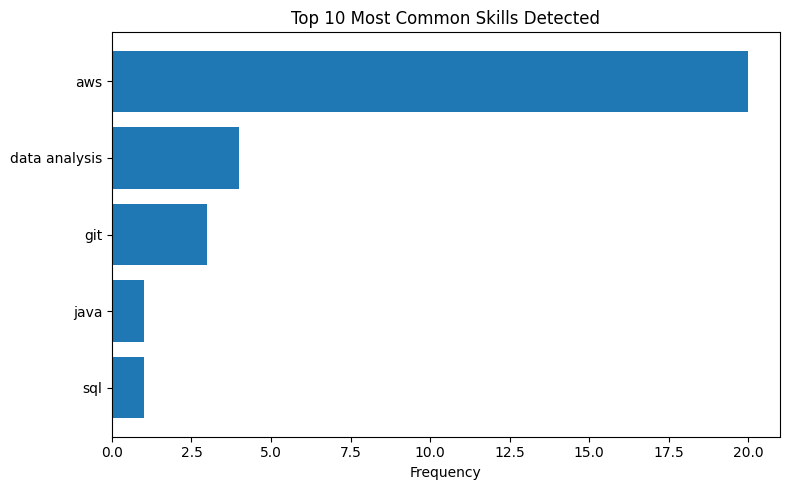

In [ ]:
all_skills = [skill for skills_list in results["skills"] for skill in skills_list]
skill_counts = Counter(all_skills)

top_skills = skill_counts.most_common(10)
if top_skills:
    labels, counts = zip(*top_skills)

    plt.figure(figsize=(8, 5))
    plt.barh(labels, counts)
    plt.xlabel("Frequency")
    plt.title("Top 10 Most Common Skills Detected")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("No skills detected in the processed sample. Try increasing SAMPLE_SIZE.")


In [12]:
OUTPUT_PATH = r"D:\Amr\Portfolio\All time project\ready to publish\NLP\Project 4\Resume_NER_extracted.csv"

readable[display_cols].to_csv(OUTPUT_PATH, index=False)
print(f"Results saved to: {OUTPUT_PATH}")


Results saved to: D:\Amr\Portfolio\All time project\ready to publish\NLP\Project 4\Resume_NER_extracted.csv
